In [ ]:
# Import libraries
import pandas as pd
import os

# =======================
# 1️ Load Raw CSV Files
# =======================
fundus_csv = '/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/EYE FUNDUS.csv'
oct_csv = '/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/OCT.csv'

df_fundus = pd.read_csv(fundus_csv)
df_oct = pd.read_csv(oct_csv)

# Add source identifiers
df_fundus['Source'] = 'Fundus'
df_oct['Source'] = 'OCT'

# =======================
# 2️ Standardize Columns
# =======================
common_columns = ['Name', 'DME', 'DR', 'Source']
df_fundus = df_fundus[common_columns]
df_oct = df_oct[common_columns]

# =======================
# 3️ Clean and Filter
# =======================
# Remove rows with missing or unknown DR/DME labels
df_fundus = df_fundus[(df_fundus['DR'] != '-') & (df_fundus['DME'] != '-')]
df_oct = df_oct[(df_oct['DR'] != '-') & (df_oct['DME'] != '-')]

# Reset indices
df_fundus.reset_index(drop=True, inplace=True)
df_oct.reset_index(drop=True, inplace=True)

# =======================
# 4️ Combine Both Modalities
# =======================
df_all = pd.concat([df_fundus, df_oct], ignore_index=True)
df_all.reset_index(drop=True, inplace=True)

# =======================
# 5️ Define Class Mappings
# =======================
DME_CLASSES = ['No_DME', 'DME']
DR_CLASSES = ['No_DR', 'NPDR', 'PDR']

NUM_DME_CLASSES = len(DME_CLASSES)
NUM_DR_CLASSES = len(DR_CLASSES)

# =======================
# 6️ Create Label Columns
# =======================
# Unified class mapping for multimodal classification
def map_final_class(row):
    if row['DR'] == 'PDR':
        return 'PDR'
    elif row['DR'] == 'NPDR':
        return 'NPDR'
    elif row['DME'] == '1':
        return 'DME'
    else:
        return 'No_DR'

df_all['Final_Class'] = df_all.apply(map_final_class, axis=1)
df_all['label'] = df_all['Final_Class'].map({
    'No_DR': 0, 'NPDR': 1, 'PDR': 2, 'DME': 3
})

# =======================
# 7️ Separate Clean Subsets
# =======================
df_fundus_only = df_all[df_all['Source'] == 'Fundus'].reset_index(drop=True)
df_oct_only = df_all[df_all['Source'] == 'OCT'].reset_index(drop=True)

# =======================
# 8️ Dataset Directories & Hyperparams
# =======================
FUNDUS_DIR = '/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/EYE FUNDUS'
OCT_DIR = '/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/OCT'

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

# =======================
# 9 Print Summary
# =======================
print("✅ Combined Dataset Loaded Successfully!\n")
print(f"Total Fundus Images: {len(pd.read_csv(fundus_csv).drop_duplicates())}")
print(f"Total OCT Images: {len(pd.read_csv(oct_csv).drop_duplicates())}")


print(f"\nNumber of DR classes: {NUM_DR_CLASSES} → {DR_CLASSES}")
print(f"Number of DME classes: {NUM_DME_CLASSES} → {DME_CLASSES}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}, Epochs: {EPOCHS}, Learning Rate: {LEARNING_RATE}")


✅ Combined Dataset Loaded Successfully!

Total Fundus Images: 1548
Total OCT Images: 1113

Number of DR classes: 3 → ['No_DR', 'NPDR', 'PDR']
Number of DME classes: 2 → ['No_DME', 'DME']
Image Size: 224x224
Batch Size: 32, Epochs: 10, Learning Rate: 0.001


In [ ]:
from torchvision import transforms

IMG_SIZE = 224
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
import pandas as pd
import os, re

# ---------- 1️⃣ Load your two CSVs ----------
fundus_df = pd.read_csv("/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/EYE FUNDUS.csv")
oct_df = pd.read_csv("/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/OCT.csv")

print("Fundus:", fundus_df.shape)
print("OCT:", oct_df.shape)

# Normalize column names
fundus_df.columns = fundus_df.columns.str.lower().str.strip()
oct_df.columns = oct_df.columns.str.lower().str.strip()

print("Fundus columns:", fundus_df.columns.tolist())
print("OCT columns:", oct_df.columns.tolist())


# -------------------------------
# 2️⃣ Normalize 'name' column for matching
# -------------------------------
def normalize_name(x):
    if pd.isna(x):
        return None
    x = str(x).strip().lower()
    x = re.sub(r'_[fo]_\d+$', '', x)   # remove camera suffix (_f_1, _o_2)
    return x

fundus_df["base_name"] = fundus_df["name"].apply(normalize_name)
oct_df["base_name"] = oct_df["name"].apply(normalize_name)


# -------------------------------
# 3️⃣ Merge on base name
# -------------------------------
df_all = pd.merge(fundus_df, oct_df, on="base_name", suffixes=("_fundus", "_oct"))
print(f"\n✅ Matched samples (both modalities): {len(df_all)}")
print(df_all.head())


# -------------------------------
# 4️⃣ Define label mapping logic
# -------------------------------
def map_label(row):
    dr_f = str(row.get("dr_fundus", "-")).upper().strip()
    dr_o = str(row.get("dr_oct", "-")).upper().strip()
    dme_f = str(row.get("dme_fundus", "-")).strip()
    dme_o = str(row.get("dme_oct", "-")).strip()

    # Case 5: both unknown → exclude
    if all(v in ["-", "NAN", "", "NONE"] for v in [dr_f, dr_o, dme_f, dme_o]):
        return None

    # Case 1: DME = 1 anywhere → DME
    if "1" in [dme_f, dme_o]:
        return "DME"

    # Case 2: DR = PDR anywhere → PDR
    if "PDR" in [dr_f, dr_o]:
        return "PDR"

    # Case 3: DR = NPDR anywhere → NPDR
    if "NPDR" in [dr_f, dr_o]:
        return "NPDR"

    # Case 4: DR = 0 & DME = 0 → Non-DME
    if all(v == "0" for v in [dr_f, dr_o, dme_f, dme_o]):
        return "Non-DME"

    return None  # anything else gets excluded


# -------------------------------
# 5️⃣ Apply label mapping
# -------------------------------
df_all["label"] = df_all.apply(map_label, axis=1)
df_all = df_all.dropna(subset=["label"])

print("\n✅ Label distribution:")
print(df_all["label"].value_counts())



Fundus: (1548, 5)
OCT: (1113, 5)
Fundus columns: ['name', 'dme', 'dr', 'size', 'format']
OCT columns: ['name', 'dme', 'dr', 'size', 'format']

✅ Matched samples (both modalities): 570
   name_fundus  dme_fundus dr_fundus size_fundus format_fundus base_name  \
0  1221_OD_f_1           0         0   1000X1000           jpg   1221_od   
1  1221_OD_f_2           0         0   1000X1000           jpg   1221_od   
2  1221_OI_f_3           0         0   1000X1000           jpg   1221_oi   
3  1221_OI_f_4           0         0   1000X1000           jpg   1221_oi   
4  1222_OD_f_1           0         0   1000X1000           jpg   1222_od   

      name_oct  dme_oct dr_oct  size_oct format_oct  
0  1221_OD_o_2        0      0  1408X573        jpg  
1  1221_OD_o_2        0      0  1408X573        jpg  
2  1221_OI_o_1        0      0  1408X573        jpg  
3  1221_OI_o_1        0      0  1408X573        jpg  
4  1222_OD_o_2        0      0  1408X573        jpg  

✅ Label distribution:
label
Non-DM

In [ ]:
# ==============================================================
# 🩺 MULTIMODAL DR + DME MODEL — CLEAN VERSION
# ==============================================================
import os, re
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# -----------------------------
# CONFIG
# -----------------------------
BATCH_SIZE = 16
EPOCHS = 10
LR = 1e-4
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CSV_PATH = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/multimodal_dataset.csv"

# ==============================================================
# 1️⃣  LOAD AND CLEAN DATA
# ==============================================================
df = pd.read_csv(CSV_PATH)

print("Before cleaning:", df.shape)

# Keep only valid rows
df = df.dropna(subset=["base_key", "DME", "DR", "fundus_path", "oct_path"])
df = df.reset_index(drop=True)

# Convert to numeric types
df["DME"] = df["DME"].astype(int)
df["DR"] = df["DR"].astype(float).astype(int)

# Extract patient_id (numbers only)
df["patient_id"] = df["base_key"].apply(lambda x: re.match(r"(\d+)", str(x)).group(1) if pd.notna(x) else None)
df = df.dropna(subset=["patient_id"]).reset_index(drop=True)

print("After cleaning:", df.shape)
print("Unique patients:", df["patient_id"].nunique())

print("\nUnique DME values:", df["DME"].unique())
print("Unique DR values:", df["DR"].unique())

# ==============================================================
# 2️⃣  STRATIFIED PATIENT-LEVEL SPLIT
# ==============================================================
# Aggregate patient-level labels
patient_labels = (
    df.groupby("patient_id")[["DME", "DR"]]
    .max()
    .reset_index()
)

# Combine DME+DR into a single stratification label
patient_labels["strata"] = patient_labels["DME"].astype(str) + "_" + patient_labels["DR"].astype(str)

print("\n🩺 Unique strata combinations:", patient_labels["strata"].unique())

# Stratified split by patient
train_pat, val_pat = train_test_split(
    patient_labels["patient_id"],
    test_size=0.15,
    random_state=42,
    stratify=patient_labels["strata"]
)

train_df = df[df["patient_id"].isin(train_pat)].reset_index(drop=True)
val_df   = df[df["patient_id"].isin(val_pat)].reset_index(drop=True)

print(f"\n✅ Train samples: {len(train_df)} | Val samples: {len(val_df)}")
print(f"Unique train patients: {train_df['patient_id'].nunique()} | Unique val patients: {val_df['patient_id'].nunique()}")

print("\n=== TRAIN DR DISTRIBUTION ===")
print(train_df["DR"].value_counts(normalize=True))
print("\n=== VAL DR DISTRIBUTION ===")
print(val_df["DR"].value_counts(normalize=True))
print("\n=== TRAIN DME DISTRIBUTION ===")
print(train_df["DME"].value_counts(normalize=True))
print("\n=== VAL DME DISTRIBUTION ===")
print(val_df["DME"].value_counts(normalize=True))

# ==============================================================
# 3️⃣  DATASET CLASS
# ==============================================================
class MultiModalDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        fundus = Image.open(row["fundus_path"]).convert("RGB")
        oct_img = Image.open(row["oct_path"]).convert("RGB")
        if self.transform:
            fundus = self.transform(fundus)
            oct_img = self.transform(oct_img)
        label = torch.tensor(row["DR"]).long()   # predicting DR here
        return fundus, oct_img, label

# ==============================================================
# 4️⃣  TRANSFORMS
# ==============================================================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = MultiModalDataset(train_df, transform)
val_ds   = MultiModalDataset(val_df, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ==============================================================
# 5️⃣  MODEL
# ==============================================================
class MultiModalEffNet(nn.Module):
    def __init__(self, num_classes=3):  # DR classes: 0,1,2
        super().__init__()
        eff = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.fundus_encoder = nn.Sequential(*list(eff.features.children()), nn.AdaptiveAvgPool2d(1))
        self.oct_encoder    = nn.Sequential(*list(eff.features.children()), nn.AdaptiveAvgPool2d(1))

        self.fc = nn.Sequential(
            nn.Linear(1280*2, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, fundus, oct_img):
        f1 = self.fundus_encoder(fundus).view(fundus.size(0), -1)
        f2 = self.oct_encoder(oct_img).view(oct_img.size(0), -1)
        x = torch.cat([f1, f2], dim=1)
        return self.fc(x)

# ==============================================================
# 6️⃣  TRAINING LOOP
# ==============================================================
model = MultiModalEffNet(num_classes=3).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

print("\n🚀 Training started...")
for epoch in range(EPOCHS):
    model.train()
    total, correct, running_loss = 0, 0, 0
    for fundus, oct_img, label in train_loader:
        fundus, oct_img, label = fundus.to(DEVICE), oct_img.to(DEVICE), label.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(fundus, oct_img)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        correct += (pred == label).sum().item()
        total += label.size(0)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.2f}% | Loss: {running_loss/len(train_loader):.4f}")

# ==============================================================
# 7️⃣  EVALUATION
# ==============================================================
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for fundus, oct_img, label in val_loader:
        fundus, oct_img, label = fundus.to(DEVICE), oct_img.to(DEVICE), label.to(DEVICE)
        outputs = model(fundus, oct_img)
        _, pred = torch.max(outputs, 1)
        y_true.extend(label.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, digits=4))

# ===================================
===========================
# 8️⃣ SAVE TRAINED MODEL
# ==============================================================
SAVE_PATH = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/dr_model.pth"
torch.save(model.state_dict(), SAVE_PATH)
print(f"\n✅ Model saved successfully at: {SAVE_PATH}")



Before cleaning: (570, 5)
After cleaning: (570, 6)
Unique patients: 217

Unique DME values: [0 1]
Unique DR values: [0 1 2]

🩺 Unique strata combinations: ['0_0' '0_1' '0_2' '1_1' '1_2']

✅ Train samples: 489 | Val samples: 81
Unique train patients: 184 | Unique val patients: 33

=== TRAIN DR DISTRIBUTION ===
DR
0    0.719836
1    0.179959
2    0.100204
Name: proportion, dtype: float64

=== VAL DR DISTRIBUTION ===
DR
0    0.777778
1    0.135802
2    0.086420
Name: proportion, dtype: float64

=== TRAIN DME DISTRIBUTION ===
DME
0    0.871166
1    0.128834
Name: proportion, dtype: float64

=== VAL DME DISTRIBUTION ===
DME
0    0.925926
1    0.074074
Name: proportion, dtype: float64
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 46.1MB/s]



🚀 Training started...
Epoch 1/10 | Train Acc: 74.44% | Loss: 0.6184
Epoch 2/10 | Train Acc: 84.25% | Loss: 0.3682
Epoch 3/10 | Train Acc: 87.32% | Loss: 0.2929
Epoch 4/10 | Train Acc: 88.96% | Loss: 0.2825
Epoch 5/10 | Train Acc: 92.23% | Loss: 0.1963
Epoch 6/10 | Train Acc: 96.32% | Loss: 0.1374
Epoch 7/10 | Train Acc: 96.73% | Loss: 0.1009
Epoch 8/10 | Train Acc: 98.77% | Loss: 0.0652
Epoch 9/10 | Train Acc: 97.75% | Loss: 0.0580
Epoch 10/10 | Train Acc: 98.57% | Loss: 0.0578

📊 Classification Report:
              precision    recall  f1-score   support

           0     0.9344    0.9048    0.9194        63
           1     0.3684    0.6364    0.4667        11
           2     0.0000    0.0000    0.0000         7

    accuracy                         0.7901        81
   macro avg     0.4343    0.5137    0.4620        81
weighted avg     0.7768    0.7901    0.7784        81


✅ Model saved successfully at: /content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/dr_model.pth


In [ ]:
# ==============================================================
# 🧠 LOAD SAVED MODEL FOR FUTURE USE
# ==============================================================

import torch
import torch.nn as nn
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1️⃣ Recreate model class (same as used in training)
class MultiModalEffNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        eff = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.fundus_encoder = nn.Sequential(*list(eff.features.children()), nn.AdaptiveAvgPool2d(1))
        self.oct_encoder = nn.Sequential(*list(eff.features.children()), nn.AdaptiveAvgPool2d(1))
        self.fc = nn.Sequential(
            nn.Linear(1280*2, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, fundus, oct_img):
        f1 = self.fundus_encoder(fundus).view(fundus.size(0), -1)
        f2 = self.oct_encoder(oct_img).view(oct_img.size(0), -1)
        x = torch.cat([f1, f2], dim=1)
        return self.fc(x)

# 2️⃣ Load saved weights
model = MultiModalEffNet(num_classes=3).to(DEVICE)
model.load_state_dict(torch.load("/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/dr_model.pth", map_location=DEVICE))
model.eval()

print("✅ Model loaded successfully — ready to use!")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 113MB/s] 


✅ Model loaded successfully — ready to use!


In [ ]:
import torch
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd

# ---------- CONFIG ----------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/dr_model.pth"
CSV_PATH = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/multimodal_dataset.csv"

# ---------- MODEL ----------
class MultiModalEffNet(torch.nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        eff = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.fundus_encoder = torch.nn.Sequential(*list(eff.features.children()), torch.nn.AdaptiveAvgPool2d(1))
        self.oct_encoder = torch.nn.Sequential(*list(eff.features.children()), torch.nn.AdaptiveAvgPool2d(1))
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(1280 * 2, 512),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.4),
            torch.nn.Linear(512, num_classes)
        )

    def forward(self, fundus, oct_img):
        f1 = self.fundus_encoder(fundus).view(fundus.size(0), -1)
        f2 = self.oct_encoder(oct_img).view(oct_img.size(0), -1)
        x = torch.cat([f1, f2], dim=1)
        return self.fc(x)

# ---------- DATASET ----------
class MultiModalDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.t = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        fundus = Image.open(r.fundus_path).convert("RGB")
        oct_img = Image.open(r.oct_path).convert("RGB")
        if self.t:
            fundus = self.t(fundus)
            oct_img = self.t(oct_img)
        label = torch.tensor(r.DR).long()
        return fundus, oct_img, label

# ---------- TRANSFORM ----------
t = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ---------- LOAD DATA ----------
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["fundus_path", "oct_path", "DR"])
val_loader = DataLoader(MultiModalDataset(df, t), batch_size=8, shuffle=False)

# ---------- LOAD MODEL ----------
model = MultiModalEffNet(num_classes=3).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# ---------- TEST ----------
correct, total = 0, 0
with torch.no_grad():
    for fundus, oct_img, label in val_loader:
        fundus, oct_img, label = fundus.to(DEVICE), oct_img.to(DEVICE), label.to(DEVICE)
        preds = model(fundus, oct_img).argmax(1)
        correct += (preds == label).sum().item()
        total += label.size(0)

print(f"\n✅ Test Accuracy: {100*correct/total:.2f}%")



✅ Test Accuracy: 90.35%


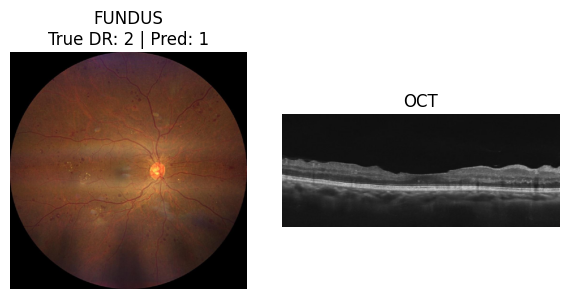

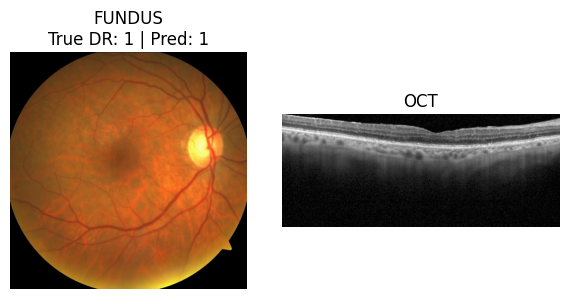

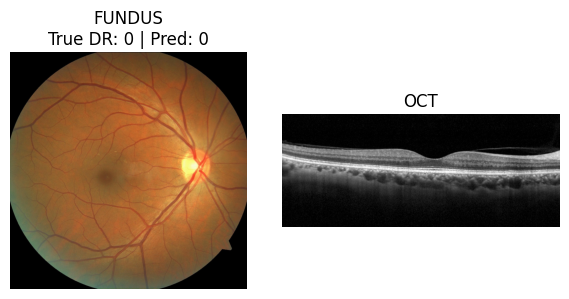

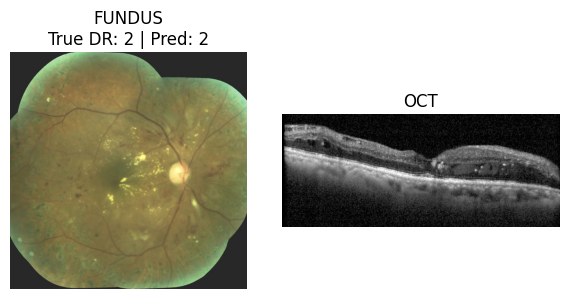

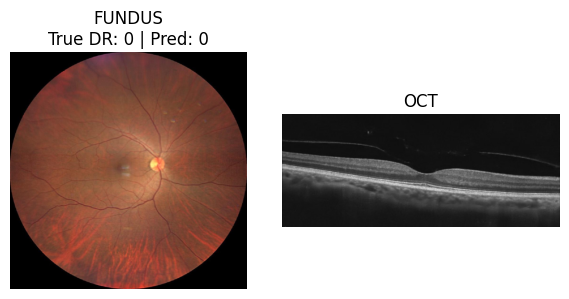

In [ ]:
import torch
from torchvision import models, transforms
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import random
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/dr_model.pth"
CSV_PATH = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/multimodal_dataset.csv"

# ---------- MODEL ----------
class MultiModalEffNet(torch.nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        eff = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.fundus_encoder = torch.nn.Sequential(*list(eff.features.children()), torch.nn.AdaptiveAvgPool2d(1))
        self.oct_encoder = torch.nn.Sequential(*list(eff.features.children()), torch.nn.AdaptiveAvgPool2d(1))
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(1280 * 2, 512),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.4),
            torch.nn.Linear(512, num_classes)
        )

    def forward(self, fundus, oct_img):
        f1 = self.fundus_encoder(fundus).view(fundus.size(0), -1)
        f2 = self.oct_encoder(oct_img).view(oct_img.size(0), -1)
        x = torch.cat([f1, f2], dim=1)
        return self.fc(x)

# ---------- LOAD MODEL ----------
model = MultiModalEffNet(num_classes=3).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# ---------- TRANSFORM ----------
t = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ---------- LOAD DATA ----------
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["fundus_path", "oct_path", "DR"])
df["DR"] = df["DR"].astype(int)

# Pick 5 random samples
samples = df.sample(5, random_state=42).reset_index(drop=True)

# ---------- PREDICT ----------
for i, row in samples.iterrows():
    # Load & preprocess both images
    fundus = t(Image.open(row["fundus_path"]).convert("RGB")).unsqueeze(0).to(DEVICE)
    oct_img = t(Image.open(row["oct_path"]).convert("RGB")).unsqueeze(0).to(DEVICE)

    # Predict
    with torch.no_grad():
        output = model(fundus, oct_img)
        pred = torch.argmax(output, dim=1).item()

    # Display
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(Image.open(row["fundus_path"]))
    axs[0].set_title(f"FUNDUS\nTrue DR: {row['DR']} | Pred: {pred}")
    axs[0].axis("off")
    axs[1].imshow(Image.open(row["oct_path"]))
    axs[1].set_title("OCT")
    axs[1].axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
from torchvision.models import densenet121

class MultiModalDenseNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # Pretrained DenseNet-121
        densenet = densenet121(weights='IMAGENET1K_V1')

        # Remove classifier (only keep feature extractor)
        self.fundus_encoder = nn.Sequential(
            densenet.features,
            nn.AdaptiveAvgPool2d((1, 1))
        )
        # Create a separate branch for OCT
        densenet2 = densenet121(weights='IMAGENET1K_V1')
        self.oct_encoder = nn.Sequential(
            densenet2.features,
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # DenseNet-121 final feature dim = 1024
        self.fc = nn.Sequential(
            nn.Linear(1024 * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, fundus, oct_img):
        f1 = self.fundus_encoder(fundus)
        f1 = torch.flatten(f1, 1)
        f2 = self.oct_encoder(oct_img)
        f2 = torch.flatten(f2, 1)
        x = torch.cat([f1, f2], dim=1)
        return self.fc(x)


In [ ]:
# -----------------------------
# CONFIG
# -----------------------------
BATCH_SIZE = 16
EPOCHS = 10
LR = 1e-4
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CSV_PATH = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/multimodal_dataset.csv"

# ==============================================================
# 1️⃣  LOAD AND CLEAN DATA
# ==============================================================
df = pd.read_csv(CSV_PATH)

print("Before cleaning:", df.shape)

# Keep only valid rows
df = df.dropna(subset=["base_key", "DME", "DR", "fundus_path", "oct_path"])
df = df.reset_index(drop=True)

# Convert to numeric types
df["DME"] = df["DME"].astype(int)
df["DR"] = df["DR"].astype(float).astype(int)

# Extract patient_id (numbers only)
df["patient_id"] = df["base_key"].apply(lambda x: re.match(r"(\d+)", str(x)).group(1) if pd.notna(x) else None)
df = df.dropna(subset=["patient_id"]).reset_index(drop=True)

print("After cleaning:", df.shape)
print("Unique patients:", df["patient_id"].nunique())

print("\nUnique DME values:", df["DME"].unique())
print("Unique DR values:", df["DR"].unique())

# ==============================================================
# 2️⃣  STRATIFIED PATIENT-LEVEL SPLIT
# ==============================================================
# Aggregate patient-level labels
patient_labels = (
    df.groupby("patient_id")[["DME", "DR"]]
    .max()
    .reset_index()
)

# Combine DME+DR into a single stratification label
patient_labels["strata"] = patient_labels["DME"].astype(str) + "_" + patient_labels["DR"].astype(str)

print("\n🩺 Unique strata combinations:", patient_labels["strata"].unique())

# Stratified split by patient
train_pat, val_pat = train_test_split(
    patient_labels["patient_id"],
    test_size=0.15,
    random_state=42,
    stratify=patient_labels["strata"]
)

train_df = df[df["patient_id"].isin(train_pat)].reset_index(drop=True)
val_df   = df[df["patient_id"].isin(val_pat)].reset_index(drop=True)

print(f"\n✅ Train samples: {len(train_df)} | Val samples: {len(val_df)}")
print(f"Unique train patients: {train_df['patient_id'].nunique()} | Unique val patients: {val_df['patient_id'].nunique()}")

print("\n=== TRAIN DR DISTRIBUTION ===")
print(train_df["DR"].value_counts(normalize=True))
print("\n=== VAL DR DISTRIBUTION ===")
print(val_df["DR"].value_counts(normalize=True))
print("\n=== TRAIN DME DISTRIBUTION ===")
print(train_df["DME"].value_counts(normalize=True))
print("\n=== VAL DME DISTRIBUTION ===")
print(val_df["DME"].value_counts(normalize=True))

# ==============================================================
# 3️⃣  DATASET CLASS
# ==============================================================
class MultiModalDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        fundus = Image.open(row["fundus_path"]).convert("RGB")
        oct_img = Image.open(row["oct_path"]).convert("RGB")
        if self.transform:
            fundus = self.transform(fundus)
            oct_img = self.transform(oct_img)
        label = torch.tensor(row["DR"]).long()
        return fundus, oct_img, label

# ==============================================================
# 4️⃣  TRANSFORMS
# ==============================================================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = MultiModalDataset(train_df, transform)
val_ds   = MultiModalDataset(val_df, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ==============================================================
# 5️⃣  MODEL — DenseNet-121
# ==============================================================
class MultiModalDenseNet(nn.Module):
    def __init__(self, num_classes=3):  # DR classes: 0,1,2
        super().__init__()

        # Load pretrained DenseNet-121
        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

        # Extract feature layers (everything except classifier)
        self.fundus_encoder = nn.Sequential(
            densenet.features,
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.oct_encoder = nn.Sequential(
            densenet.features,
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # DenseNet-121 has 1024 features after pooling
        self.fc = nn.Sequential(
            nn.Linear(1024*2, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, fundus, oct_img):
        f1 = self.fundus_encoder(fundus).view(fundus.size(0), -1)
        f2 = self.oct_encoder(oct_img).view(oct_img.size(0), -1)
        x = torch.cat([f1, f2], dim=1)
        return self.fc(x)

# ==============================================================
# 6️⃣  TRAINING LOOP
# ==============================================================
model = MultiModalDenseNet(num_classes=3).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

print("\n🚀 Training started with DenseNet-121...")
for epoch in range(EPOCHS):
    model.train()
    total, correct, running_loss = 0, 0, 0
    for fundus, oct_img, label in train_loader:
        fundus, oct_img, label = fundus.to(DEVICE), oct_img.to(DEVICE), label.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(fundus, oct_img)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        correct += (pred == label).sum().item()
        total += label.size(0)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.2f}% | Loss: {running_loss/len(train_loader):.4f}")

# ==============================================================
# 7️⃣  EVALUATION
# ==============================================================
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for fundus, oct_img, label in val_loader:
        fundus, oct_img, label = fundus.to(DEVICE), oct_img.to(DEVICE), label.to(DEVICE)
        outputs = model(fundus, oct_img)
        _, pred = torch.max(outputs, 1)
        y_true.extend(label.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

print("\n📊 DenseNet-121 Classification Report:")
print(classification_report(y_true, y_pred, digits=4))

# ==============================================================
# 8️⃣ SAVE TRAINED MODEL
# ==============================================================
SAVE_PATH = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/dr_model_densenet.pth"
torch.save(model.state_dict(), SAVE_PATH)
print(f"\n✅ Model saved successfully at: {SAVE_PATH}")

Before cleaning: (570, 5)
After cleaning: (570, 6)
Unique patients: 217

Unique DME values: [0 1]
Unique DR values: [0 1 2]

🩺 Unique strata combinations: ['0_0' '0_1' '0_2' '1_1' '1_2']

✅ Train samples: 489 | Val samples: 81
Unique train patients: 184 | Unique val patients: 33

=== TRAIN DR DISTRIBUTION ===
DR
0    0.719836
1    0.179959
2    0.100204
Name: proportion, dtype: float64

=== VAL DR DISTRIBUTION ===
DR
0    0.777778
1    0.135802
2    0.086420
Name: proportion, dtype: float64

=== TRAIN DME DISTRIBUTION ===
DME
0    0.871166
1    0.128834
Name: proportion, dtype: float64

=== VAL DME DISTRIBUTION ===
DME
0    0.925926
1    0.074074
Name: proportion, dtype: float64
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 134MB/s]



🚀 Training started with DenseNet-121...
Epoch 1/10 | Train Acc: 74.03% | Loss: 0.6074
Epoch 2/10 | Train Acc: 83.44% | Loss: 0.3712
Epoch 3/10 | Train Acc: 87.73% | Loss: 0.2723
Epoch 4/10 | Train Acc: 94.68% | Loss: 0.1732
Epoch 5/10 | Train Acc: 96.73% | Loss: 0.1055
Epoch 6/10 | Train Acc: 97.75% | Loss: 0.0714
Epoch 7/10 | Train Acc: 98.98% | Loss: 0.0431
Epoch 8/10 | Train Acc: 98.57% | Loss: 0.0501
Epoch 9/10 | Train Acc: 97.55% | Loss: 0.0609
Epoch 10/10 | Train Acc: 97.55% | Loss: 0.0530

📊 DenseNet-121 Classification Report:
              precision    recall  f1-score   support

           0     0.8630    1.0000    0.9265        63
           1     0.5714    0.3636    0.4444        11
           2     1.0000    0.1429    0.2500         7

    accuracy                         0.8395        81
   macro avg     0.8115    0.5022    0.5403        81
weighted avg     0.8353    0.8395    0.8025        81


✅ Model saved successfully at: /content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATA

In [ ]:
# ==============================================================
# TESTING SCRIPT - MULTIMODAL DENSENET-121 DR CLASSIFICATION
# ==============================================================

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split

# -----------------------------
# CONFIG
# -----------------------------
BATCH_SIZE = 16
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CSV_PATH = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/multimodal_dataset.csv"
MODEL_PATH = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/dr_model_densenet.pth"

# ==============================================================
# LOAD TEST DATA
# ==============================================================
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["base_key", "DME", "DR", "fundus_path", "oct_path"]).reset_index(drop=True)
df["DME"] = df["DME"].astype(int)
df["DR"] = df["DR"].astype(float).astype(int)
df["patient_id"] = df["base_key"].apply(lambda x: re.match(r"(\d+)", str(x)).group(1) if pd.notna(x) else None)
df = df.dropna(subset=["patient_id"]).reset_index(drop=True)

# Patient-level split
patient_labels = df.groupby("patient_id")[["DME", "DR"]].max().reset_index()
patient_labels["strata"] = patient_labels["DME"].astype(str) + "_" + patient_labels["DR"].astype(str)

train_pat, test_pat = train_test_split(
    patient_labels["patient_id"],
    test_size=0.15,
    random_state=42,
    stratify=patient_labels["strata"]
)

test_df = df[df["patient_id"].isin(test_pat)].reset_index(drop=True)
#print(f"Test samples: {len(test_df)}")

# ==============================================================
# DATASET CLASS
# ==============================================================
class MultiModalDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        fundus = Image.open(row["fundus_path"]).convert("RGB")
        oct_img = Image.open(row["oct_path"]).convert("RGB")
        if self.transform:
            fundus = self.transform(fundus)
            oct_img = self.transform(oct_img)
        label = torch.tensor(row["DR"]).long()
        return fundus, oct_img, label

# ==============================================================
# TEST TRANSFORM
# ==============================================================
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_ds = MultiModalDataset(test_df, test_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ==============================================================
# MODEL ARCHITECTURE
# ==============================================================
class MultiModalDenseNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.fundus_encoder = nn.Sequential(
            densenet.features,
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.oct_encoder = nn.Sequential(
            densenet.features,
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Sequential(
            nn.Linear(1024*2, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, fundus, oct_img):
        f1 = self.fundus_encoder(fundus).view(fundus.size(0), -1)
        f2 = self.oct_encoder(oct_img).view(oct_img.size(0), -1)
        x = torch.cat([f1, f2], dim=1)
        return self.fc(x)

# ==============================================================
# LOAD MODEL & TEST
# ==============================================================
model = MultiModalDenseNet(num_classes=3).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

print("Testing...")
y_true, y_pred = [], []
with torch.no_grad():
    for fundus, oct_img, label in test_loader:
        fundus, oct_img, label = fundus.to(DEVICE), oct_img.to(DEVICE), label.to(DEVICE)
        outputs = model(fundus, oct_img)
        _, pred = torch.max(outputs, 1)
        y_true.extend(label.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

# ==============================================================
# RESULTS
# ==============================================================
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['No DR', 'Mild DR', 'Severe DR'], digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No DR', 'Mild DR', 'Severe DR'],
            yticklabels=['No DR', 'Mild DR', 'Severe DR'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=300)
plt.show()

print("\n✅ Testing complete!")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import cv2

# -----------------------------
# Load trained model
# -----------------------------
model = MultiModalEffNet(num_classes=3).to(DEVICE)
model.load_state_dict(torch.load("/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/dr_model.pth", map_location=DEVICE))
model.eval()

# -----------------------------
# Choose one Fundus + OCT image
# -----------------------------
oct_path = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/OCT/OCT1/1221_OD_o_2.jpg"
fundus_path = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/EYE FUNDUS/EYE FUNDUS11/1221_OD_f_2.jpg"

# -----------------------------
# Preprocessing (same as training)
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

fundus = transform(Image.open(fundus_path).convert("RGB")).unsqueeze(0).to(DEVICE)
oct_img = transform(Image.open(oct_path).convert("RGB")).unsqueeze(0).to(DEVICE)


In [ ]:
import os
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.utils import save_image

# -----------------------------
# CONFIG
# -----------------------------
BATCH_SIZE      = 16
EPOCHS          = 10
LR              = 1e-4
IMG_SIZE        = 224
GAN_EPOCHS      = 20          # epochs to train each GAN
GAN_LR          = 2e-4
LATENT_DIM      = 100
NUM_DR_CLASSES  = 3            # 0=No DR, 1=NPDR, 2=PDR
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CSV_PATH = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/multimodal_dataset.csv"

# ==============================================================
# 1  LOAD AND CLEAN DATA
# ==============================================================
df = pd.read_csv(CSV_PATH)
print("Before cleaning:", df.shape)

df = df.dropna(subset=["base_key", "DME", "DR", "fundus_path", "oct_path"])
df = df.reset_index(drop=True)
df["DME"] = df["DME"].astype(int)
df["DR"]  = df["DR"].astype(float).astype(int)
df["patient_id"] = df["base_key"].apply(
    lambda x: re.match(r"(\d+)", str(x)).group(1) if pd.notna(x) else None
)
df = df.dropna(subset=["patient_id"]).reset_index(drop=True)

print("After cleaning:", df.shape)
print("Unique patients:", df["patient_id"].nunique())
print("DR distribution:\n",  df["DR"].value_counts())
print("DME distribution:\n", df["DME"].value_counts())

# ==============================================================
# 2  STRATIFIED PATIENT-LEVEL SPLIT
# ==============================================================
patient_labels = (
    df.groupby("patient_id")[["DME", "DR"]]
    .max()
    .reset_index()
)
patient_labels["strata"] = (
    patient_labels["DME"].astype(str) + "_" + patient_labels["DR"].astype(str)
)

train_pat, val_pat = train_test_split(
    patient_labels["patient_id"],
    test_size=0.15,
    random_state=42,
    stratify=patient_labels["strata"]
)

train_df = df[df["patient_id"].isin(train_pat)].reset_index(drop=True)
val_df   = df[df["patient_id"].isin(val_pat)].reset_index(drop=True)

print(f"\nTrain samples: {len(train_df)} | Val samples: {len(val_df)}")

# ==============================================================
# 3  GAN DATASET HELPERS
# ==============================================================
class SingleModalDataset(Dataset):
    """Loads one modality (fundus OR oct) with its label."""
    def __init__(self, dataframe, path_col, label_col, transform=None):
        self.data      = dataframe
        self.path_col  = path_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data.iloc[idx]
        img   = Image.open(row[self.path_col]).convert("RGB")
        label = int(row[self.label_col])
        if self.transform:
            img = self.transform(img)
        return img, label


# Small-resolution transform for GAN training (64x64 keeps training fast)
gan_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ==============================================================
# 4  CGAN  — for Fundus images  (condition on DR class)
# ==============================================================
class CGANGenerator(nn.Module):
    """Conditional GAN generator.
       Input: noise (LATENT_DIM) + one-hot class label
       Output: 3 × 64 × 64 image
    """
    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_DR_CLASSES, img_channels=3):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        input_dim = latent_dim + num_classes

        self.net = nn.Sequential(
            # 1 × 1
            nn.ConvTranspose2d(input_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
            # 4 × 4
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            # 8 × 8
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            # 16 × 16
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),  nn.ReLU(True),
            # 32 × 32
            nn.ConvTranspose2d(64, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
            # 64 × 64
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)                        # (B, num_classes)
        x = torch.cat([noise, label_input], dim=1)                  # (B, latent+num_classes)
        x = x.unsqueeze(-1).unsqueeze(-1)                           # (B, C, 1, 1)
        return self.net(x)


class CGANDiscriminator(nn.Module):
    """Conditional discriminator.
       Input: image + label map (label broadcast to all pixels)
    """
    def __init__(self, num_classes=NUM_DR_CLASSES, img_channels=3):
        super().__init__()
        # Embed label into a spatial map concatenated with image
        self.label_emb = nn.Embedding(num_classes, num_classes)
        in_ch = img_channels + num_classes

        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 64,  4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64,  128,  4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256,  4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 512,  4, 2, 1, bias=False), nn.BatchNorm2d(512), nn.LeakyReLU(0.2, True),
            nn.Conv2d(512,   1,  4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        # Broadcast label to spatial map: (B, num_classes, H, W)
        label_map = self.label_emb(labels)                          # (B, num_classes)
        label_map = label_map.unsqueeze(-1).unsqueeze(-1)           # (B, num_classes, 1, 1)
        label_map = label_map.expand(-1, -1, img.size(2), img.size(3))
        x = torch.cat([img, label_map], dim=1)
        return self.net(x).view(-1)


# ==============================================================
# 5  DCGAN  — for OCT images  (binary: DME positive / negative)
# ==============================================================
class DCGANGenerator(nn.Module):
    """Standard DCGAN generator — no class conditioning needed
       because we train one generator per DME class.
       Output: 3 × 64 × 64
    """
    def __init__(self, latent_dim=LATENT_DIM, img_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128,  64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d( 64,   img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z.unsqueeze(-1).unsqueeze(-1))


class DCGANDiscriminator(nn.Module):
    def __init__(self, img_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, 64,  4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64,  128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False), nn.BatchNorm2d(512), nn.LeakyReLU(0.2, True),
            nn.Conv2d(512,   1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img).view(-1)


# ==============================================================
# 6  GENERIC GAN TRAINING LOOP
# ==============================================================
def weights_init(m):
    """DCGAN-style weight initialisation."""
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


def train_cgan(train_df, epochs=GAN_EPOCHS):
    """Train CGAN on fundus images conditioned on DR label (0/1/2)."""
    print("\n--- Training CGAN on Fundus images ---")

    dataset    = SingleModalDataset(train_df, "fundus_path", "DR", gan_transform)
    loader     = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, drop_last=True)

    G = CGANGenerator().to(DEVICE).apply(weights_init)
    D = CGANDiscriminator().to(DEVICE).apply(weights_init)
    opt_G = torch.optim.Adam(G.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        for real_imgs, labels in loader:
            real_imgs = real_imgs.to(DEVICE)
            labels    = labels.to(DEVICE)
            b         = real_imgs.size(0)

            real_label = torch.ones(b, device=DEVICE)
            fake_label = torch.zeros(b, device=DEVICE)

            # --- Discriminator ---
            opt_D.zero_grad()
            d_real = D(real_imgs, labels)
            loss_d_real = criterion(d_real, real_label)

            noise     = torch.randn(b, LATENT_DIM, device=DEVICE)
            fake_imgs = G(noise, labels)
            d_fake    = D(fake_imgs.detach(), labels)
            loss_d_fake = criterion(d_fake, fake_label)

            loss_D = (loss_d_real + loss_d_fake) / 2
            loss_D.backward()
            opt_D.step()

            # --- Generator ---
            opt_G.zero_grad()
            d_fake2  = D(fake_imgs, labels)
            loss_G   = criterion(d_fake2, real_label)
            loss_G.backward()
            opt_G.step()

        if (epoch + 1) % 10 == 0:
            print(f"  CGAN Epoch {epoch+1}/{epochs} | D: {loss_D.item():.4f} | G: {loss_G.item():.4f}")

    print("CGAN training complete.")
    return G


def train_dcgan_for_class(train_df, dme_class, epochs=GAN_EPOCHS):
    """Train a DCGAN on OCT images for a specific DME class (0 or 1)."""
    subset  = train_df[train_df["DME"] == dme_class].reset_index(drop=True)
    print(f"\n--- Training DCGAN on OCT images (DME={dme_class}, n={len(subset)}) ---")

    if len(subset) < 10:
        print(f"  Skipping — not enough samples for DME={dme_class}")
        return None

    dataset = SingleModalDataset(subset, "oct_path", "DME", gan_transform)
    loader  = DataLoader(dataset, batch_size=min(64, len(subset)), shuffle=True,
                         num_workers=2, drop_last=True)

    G = DCGANGenerator().to(DEVICE).apply(weights_init)
    D = DCGANDiscriminator().to(DEVICE).apply(weights_init)
    opt_G = torch.optim.Adam(G.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        for real_imgs, _ in loader:
            real_imgs  = real_imgs.to(DEVICE)
            b          = real_imgs.size(0)
            real_label = torch.ones(b,  device=DEVICE)
            fake_label = torch.zeros(b, device=DEVICE)

            # Discriminator
            opt_D.zero_grad()
            noise     = torch.randn(b, LATENT_DIM, device=DEVICE)
            fake_imgs = G(noise)
            loss_D = (criterion(D(real_imgs), real_label) +
                      criterion(D(fake_imgs.detach()), fake_label)) / 2
            loss_D.backward()
            opt_D.step()

            # Generator
            opt_G.zero_grad()
            loss_G = criterion(D(G(torch.randn(b, LATENT_DIM, device=DEVICE))), real_label)
            loss_G.backward()
            opt_G.step()

        if (epoch + 1) % 10 == 0:
            print(f"  DCGAN (DME={dme_class}) Epoch {epoch+1}/{epochs} | D: {loss_D.item():.4f} | G: {loss_G.item():.4f}")

    print(f"DCGAN (DME={dme_class}) training complete.")
    return G


# ==============================================================
# 7  GENERATE SYNTHETIC IMAGES  →  augmented in-memory tensors
# ==============================================================
def generate_fundus_samples(G_cgan, dr_class, n_samples):
    """Generate n_samples fundus images for a given DR class."""
    G_cgan.eval()
    with torch.no_grad():
        noise  = torch.randn(n_samples, LATENT_DIM, device=DEVICE)
        labels = torch.full((n_samples,), dr_class, dtype=torch.long, device=DEVICE)
        imgs   = G_cgan(noise, labels).cpu()       # (N, 3, 64, 64)  range [-1,1]
    return imgs


def generate_oct_samples(G_dcgan, n_samples):
    """Generate n_samples OCT images from a DCGAN."""
    G_dcgan.eval()
    with torch.no_grad():
        noise = torch.randn(n_samples, LATENT_DIM, device=DEVICE)
        imgs  = G_dcgan(noise).cpu()
    return imgs


def compute_augmentation_targets(train_df):
    """How many synthetic samples to generate per class to balance."""
    dr_counts  = train_df["DR"].value_counts()
    dme_counts = train_df["DME"].value_counts()

    max_dr  = dr_counts.max()
    max_dme = dme_counts.max()

    dr_needed  = {cls: int(max_dr  - cnt) for cls, cnt in dr_counts.items()}
    dme_needed = {cls: int(max_dme - cnt) for cls, cnt in dme_counts.items()}

    print("\nDR augmentation targets:", dr_needed)
    print("DME augmentation targets:", dme_needed)
    return dr_needed, dme_needed


# ==============================================================
# 8  AUGMENTED DATASET  (real + synthetic tensors)
# ==============================================================
class AugmentedMultiModalDataset(Dataset):
    """
    Combines real image paths with pre-generated synthetic tensors.
    Synthetic fundus tensors carry DR labels.
    Synthetic OCT tensors carry DME labels (mapped to DR=0 placeholder).
    """
    def __init__(self, real_df, transform,
                 syn_fundus=None,   # list of (tensor_3x64x64, dr_label)
                 syn_oct=None):     # list of (tensor_3x64x64, dme_label)  — kept for DME head
        self.real_df    = real_df
        self.transform  = transform
        self.syn_fundus = syn_fundus or []
        self.syn_oct    = syn_oct    or []

        # Upscale transform for synthetic 64×64 images → 224×224
        self.resize_syn = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.real_df) + len(self.syn_fundus)

    def __getitem__(self, idx):
        if idx < len(self.real_df):
            row     = self.real_df.iloc[idx]
            fundus  = Image.open(row["fundus_path"]).convert("RGB")
            oct_img = Image.open(row["oct_path"]).convert("RGB")
            if self.transform:
                fundus  = self.transform(fundus)
                oct_img = self.transform(oct_img)
            label = torch.tensor(row["DR"]).long()
        else:
            # Synthetic fundus — pair with a real OCT randomly
            syn_idx    = idx - len(self.real_df)
            syn_tensor, dr_label = self.syn_fundus[syn_idx]

            # Convert synthetic [-1,1] tensor back to [0,1] then resize
            syn_tensor_01 = (syn_tensor + 1) / 2
            fundus  = self.resize_syn(syn_tensor_01)

            # Pair with a random real OCT from train set
            real_row  = self.real_df.sample(1).iloc[0]
            oct_img   = Image.open(real_row["oct_path"]).convert("RGB")
            if self.transform:
                oct_img = self.transform(oct_img)

            label = torch.tensor(dr_label).long()

        return fundus, oct_img, label


# ==============================================================
# 9  MULTIMODAL DENSENET-121
# ==============================================================
class MultiModalDenseNet(nn.Module):
    def __init__(self, num_classes=NUM_DR_CLASSES):
        super().__init__()
        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        features = densenet.features

        self.fundus_encoder = nn.Sequential(
            features, nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d((1, 1))
        )
        # Separate copy for OCT so weights diverge
        densenet2 = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.oct_encoder = nn.Sequential(
            densenet2.features, nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d((1, 1))
        )

        self.fc = nn.Sequential(
            nn.Linear(1024 * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, fundus, oct_img):
        f1 = self.fundus_encoder(fundus).view(fundus.size(0), -1)
        f2 = self.oct_encoder(oct_img).view(oct_img.size(0), -1)
        return self.fc(torch.cat([f1, f2], dim=1))


# ==============================================================
# 10  TRANSFORMS FOR CLASSIFIER
# ==============================================================
clf_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


# ==============================================================
# 11  MAIN  —  TRAIN GANs → AUGMENT → TRAIN CLASSIFIER
# ==============================================================
if __name__ == "__main__":

    # ── Step A: Train CGAN on fundus ──────────────────────────
    G_cgan = train_cgan(train_df, epochs=GAN_EPOCHS)

    # ── Step B: Train DCGAN for each OCT class ────────────────
    G_dcgan_dme0 = train_dcgan_for_class(train_df, dme_class=0, epochs=GAN_EPOCHS)
    G_dcgan_dme1 = train_dcgan_for_class(train_df, dme_class=1, epochs=GAN_EPOCHS)

    # ── Step C: Figure out how many samples to generate ───────
    dr_needed, dme_needed = compute_augmentation_targets(train_df)

    # ── Step D: Generate synthetic fundus tensors ─────────────
    syn_fundus = []
    for dr_cls, n in dr_needed.items():
        if n > 0:
            print(f"  Generating {n} synthetic fundus images for DR class {dr_cls}")
            tensors = generate_fundus_samples(G_cgan, dr_cls, n)
            syn_fundus.extend([(t, dr_cls) for t in tensors])

    # ── Step E: Generate synthetic OCT tensors (for reference) ─
    syn_oct = []
    dcgan_map = {0: G_dcgan_dme0, 1: G_dcgan_dme1}
    for dme_cls, n in dme_needed.items():
        if n > 0 and dcgan_map.get(dme_cls) is not None:
            print(f"  Generating {n} synthetic OCT images for DME class {dme_cls}")
            tensors = generate_oct_samples(dcgan_map[dme_cls], n)
            syn_oct.extend([(t, dme_cls) for t in tensors])

    # ── Step F: Build augmented datasets ──────────────────────
    train_ds = AugmentedMultiModalDataset(
        train_df, clf_transform,
        syn_fundus=syn_fundus,
        syn_oct=syn_oct
    )
    val_ds = AugmentedMultiModalDataset(val_df, clf_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"\nAugmented train size : {len(train_ds)}")
    print(f"Validation size      : {len(val_ds)}")

    # ── Step G: Train classifier ───────────────────────────────
    model     = MultiModalDenseNet(num_classes=NUM_DR_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    print("\nTraining DenseNet-121 on GAN-augmented data...")
    for epoch in range(EPOCHS):
        model.train()
        total, correct, running_loss = 0, 0, 0.0
        for fundus, oct_img, label in train_loader:
            fundus, oct_img, label = fundus.to(DEVICE), oct_img.to(DEVICE), label.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(fundus, oct_img)
            loss    = criterion(outputs, label)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, pred  = torch.max(outputs, 1)
            correct  += (pred == label).sum().item()
            total    += label.size(0)

        train_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{EPOCHS} | Acc: {train_acc:.2f}% | Loss: {running_loss/len(train_loader):.4f}")

    # ── Step H: Evaluate ──────────────────────────────────────
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for fundus, oct_img, label in val_loader:
            fundus, oct_img, label = fundus.to(DEVICE), oct_img.to(DEVICE), label.to(DEVICE)
            _, pred = torch.max(model(fundus, oct_img), 1)
            y_true.extend(label.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    print("\nClassification Report (GAN-Augmented DenseNet-121):")
    print(classification_report(y_true, y_pred,
                                 target_names=["No DR", "NPDR", "PDR"],
                                 digits=4))

    # ── Step I: Save ──────────────────────────────────────────
    BASE = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/"
    torch.save(model.state_dict(),    BASE + "dr_model_densenet_gan.pth")
    torch.save(G_cgan.state_dict(),   BASE + "cgan_fundus_generator.pth")
    if G_dcgan_dme1:
        torch.save(G_dcgan_dme1.state_dict(), BASE + "dcgan_oct_dme1_generator.pth")
    print("\nAll models saved.")

Before cleaning: (570, 5)
After cleaning: (570, 6)
Unique patients: 217
DR distribution:
 DR
0    415
1     99
2     56
Name: count, dtype: int64
DME distribution:
 DME
0    501
1     69
Name: count, dtype: int64

Train samples: 489 | Val samples: 81

--- Training CGAN on Fundus images ---
  CGAN Epoch 10/20 | D: 0.4461 | G: 4.0743
  CGAN Epoch 20/20 | D: 0.3337 | G: 4.5948
CGAN training complete.

--- Training DCGAN on OCT images (DME=0, n=426) ---
  DCGAN (DME=0) Epoch 10/20 | D: 0.0000 | G: 40.5444
  DCGAN (DME=0) Epoch 20/20 | D: 0.0000 | G: 40.4015
DCGAN (DME=0) training complete.

--- Training DCGAN on OCT images (DME=1, n=63) ---
  DCGAN (DME=1) Epoch 10/20 | D: 0.0413 | G: 7.8598
  DCGAN (DME=1) Epoch 20/20 | D: 0.0169 | G: 9.3966
DCGAN (DME=1) training complete.

DR augmentation targets: {0: 0, 1: 264, 2: 303}
DME augmentation targets: {0: 0, 1: 363}
  Generating 264 synthetic fundus images for DR class 1
  Generating 303 synthetic fundus images for DR class 2
  Generating 363

100%|██████████| 30.8M/30.8M [00:00<00:00, 193MB/s]



Training DenseNet-121 on GAN-augmented data...
Epoch 1/10 | Acc: 67.14% | Loss: 0.6565
Epoch 2/10 | Acc: 84.38% | Loss: 0.3655
Epoch 3/10 | Acc: 91.76% | Loss: 0.2111
Epoch 4/10 | Acc: 93.18% | Loss: 0.1584
Epoch 5/10 | Acc: 95.17% | Loss: 0.1277
Epoch 6/10 | Acc: 95.93% | Loss: 0.1051
Epoch 7/10 | Acc: 94.13% | Loss: 0.1351
Epoch 8/10 | Acc: 96.59% | Loss: 0.0984
Epoch 9/10 | Acc: 98.39% | Loss: 0.0456
Epoch 10/10 | Acc: 98.67% | Loss: 0.0438

Classification Report (GAN-Augmented DenseNet-121):
              precision    recall  f1-score   support

       No DR     0.9538    0.9841    0.9688        63
        NPDR     0.5714    0.7273    0.6400        11
         PDR     1.0000    0.2857    0.4444         7

    accuracy                         0.8889        81
   macro avg     0.8418    0.6657    0.6844        81
weighted avg     0.9059    0.8889    0.8788        81


All models saved.


In [ ]:
# Fundus Grad-CAM
fundus_cam, fundus_pred = get_gradcam_heatmap(model, target_layer_fundus, fundus, oct_img)

# OCT Grad-CAM
oct_cam, oct_pred = get_gradcam_heatmap(model, target_layer_oct, oct_img, fundus)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


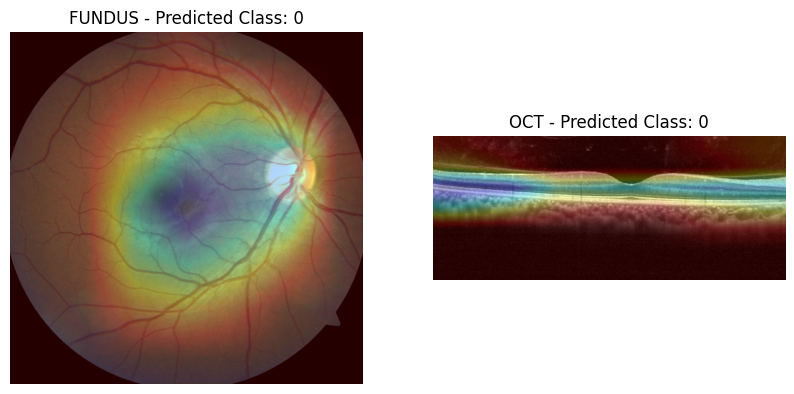

In [ ]:
def show_gradcam(image_path, cam):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = np.float32(heatmap) * 0.4 + np.float32(img)
    overlay = overlay / np.max(overlay)
    plt.imshow(overlay)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title(f"FUNDUS - Predicted Class: {fundus_pred}")
show_gradcam(fundus_path, fundus_cam)

plt.subplot(1,2,2)
plt.title(f"OCT - Predicted Class: {oct_pred}")
show_gradcam(oct_path, oct_cam)
plt.show()


In [ ]:
print(type(fundus), fundus.shape)
print(type(oct_img), oct_img.shape)


<class 'torch.Tensor'> torch.Size([1, 3, 224, 224])
<class 'torch.Tensor'> torch.Size([1, 3, 224, 224])


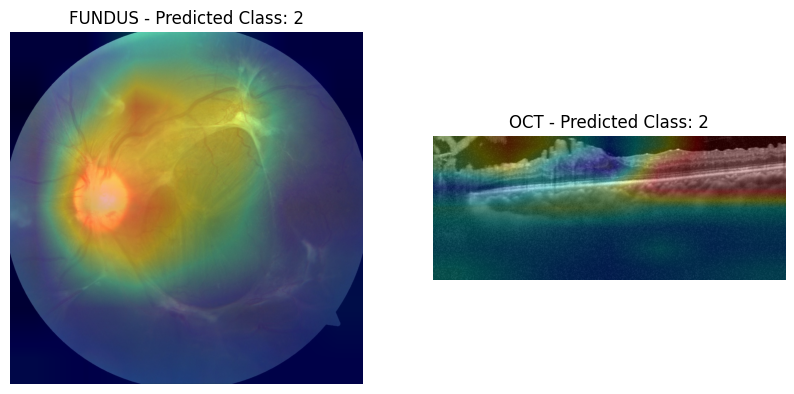

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import cv2

# -----------------------------
# Load trained model
# -----------------------------
model = MultiModalEffNet(num_classes=3).to(DEVICE)
model.load_state_dict(torch.load("/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/dr_model.pth", map_location=DEVICE))
model.eval()

# -----------------------------
# Choose one Fundus + OCT image
# -----------------------------
oct_path = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/OCT/OCT1/1245_OI_o_1.jpg"
fundus_path = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/EYE FUNDUS/EYE FUNDUS11/1245_OI_f_3.jpg"

# -----------------------------
# Preprocessing (same as training)
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

fundus = transform(Image.open(fundus_path).convert("RGB")).unsqueeze(0).to(DEVICE)
oct_img = transform(Image.open(oct_path).convert("RGB")).unsqueeze(0).to(DEVICE)
# Pick the last convolution block from EfficientNet
target_layer_fundus = model.fundus_encoder[-2][-1]  # Last block
target_layer_oct = model.oct_encoder[-2][-1]

def get_gradcam_heatmap(model, target_layer, img_tensor, other_tensor):
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    # Register hooks
    fwd = target_layer.register_forward_hook(forward_hook)
    bwd = target_layer.register_backward_hook(backward_hook)

    # Forward + Backward
    output = model(img_tensor, other_tensor)
    class_idx = output.argmax(dim=1).item()
    model.zero_grad()
    output[0, class_idx].backward()

    # Compute Grad-CAM
    grads = gradients[0].mean(dim=[2,3], keepdim=True)
    acts = activations[0]
    cam = (acts * grads).sum(dim=1).squeeze().cpu().detach().numpy()
    cam = np.maximum(cam, 0)
    cam = cam / cam.max()

    # Clean up hooks
    fwd.remove()
    bwd.remove()

    return cam, class_idx
# Fundus Grad-CAM
fundus_cam, fundus_pred = get_gradcam_heatmap(model, target_layer_fundus, fundus, oct_img)

# OCT Grad-CAM
oct_cam, oct_pred = get_gradcam_heatmap(model, target_layer_oct, oct_img, fundus)
def show_gradcam(image_path, cam):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = np.float32(heatmap) * 0.4 + np.float32(img)
    overlay = overlay / np.max(overlay)
    plt.imshow(overlay)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title(f"FUNDUS - Predicted Class: {fundus_pred}")
show_gradcam(fundus_path, fundus_cam)

plt.subplot(1,2,2)
plt.title(f"OCT - Predicted Class: {oct_pred}")
show_gradcam(oct_path, oct_cam)
plt.show()


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

def occlusion_sensitivity_multimodal(
    model,
    fundus_img,
    oct_img,
    modality="fundus",   # "fundus" or "oct"
    patch_size=32,
    stride=16,
    target_class=None,
    device="cuda"
):
    model.eval()
    fundus_img = fundus_img.to(device)
    oct_img = oct_img.to(device)

    with torch.no_grad():
        original_output = model(fundus_img, oct_img)
        probs = F.softmax(original_output, dim=1)

        if target_class is None:
            target_class = torch.argmax(probs, dim=1).item()

        original_score = probs[0, target_class].item()

    _, _, H, W = fundus_img.shape
    heatmap = np.zeros((H, W))

    for y in range(0, H - patch_size, stride):
        for x in range(0, W - patch_size, stride):

            fundus_copy = fundus_img.clone()
            oct_copy = oct_img.clone()

            if modality == "fundus":
                fundus_copy[:, :, y:y+patch_size, x:x+patch_size] = 0
            else:
                oct_copy[:, :, y:y+patch_size, x:x+patch_size] = 0

            with torch.no_grad():
                output = model(fundus_copy, oct_copy)
                probs = F.softmax(output, dim=1)
                occluded_score = probs[0, target_class].item()

            importance = original_score - occluded_score

            heatmap[y:y+patch_size, x:x+patch_size] += importance

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    return heatmap, target_class

In [ ]:
from PIL import Image
from torchvision import transforms

# Define same transforms used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load images
fundus_img = Image.open("/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/EYE FUNDUS/EYE FUNDUS1/0001_OD_f_1.jpg").convert("RGB")
oct_img = Image.open("/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/OCT/OCT1/1221_OD_o_2.jpg").convert("RGB")

# Convert to tensor and add batch dimension
fundus_tensor = transform(fundus_img).unsqueeze(0).to(DEVICE)
oct_tensor = transform(oct_img).unsqueeze(0).to(DEVICE)

print(fundus_tensor.shape)  # Should be (1, 3, 224, 224)

torch.Size([1, 3, 224, 224])


In [ ]:
heatmap, pred_class = occlusion_sensitivity_multimodal(
    model=model,
    fundus_img=fundus_tensor,
    oct_img=oct_tensor,
    modality="fundus",
    device=DEVICE
)

print("Predicted Class Index:", pred_class)

Predicted Class Index: 0


In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=04dbd875024aff339e650bed66bf6596635aad200a23cf5d31050300b6871b0e
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


  0%|          | 0/1000 [00:00<?, ?it/s]

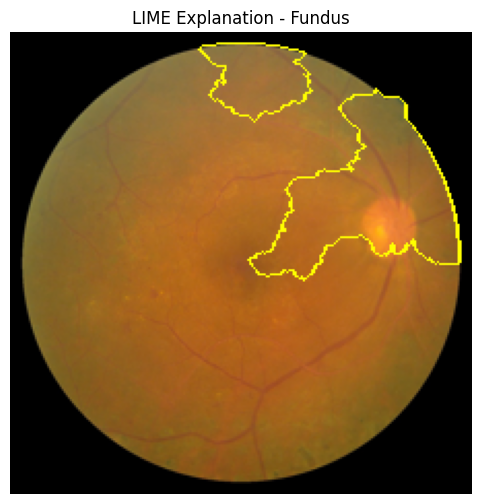

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# -------------------------------------------------
# 1️⃣ Load & preprocess images
# -------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

fundus_path = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/EYE FUNDUS/EYE FUNDUS10/1071_OD_f_1.jpg"
oct_path = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/OCT/OCT1/1221_OI_o_1.jpg"

fundus_pil = Image.open(fundus_path).convert("RGB")
oct_pil = Image.open(oct_path).convert("RGB")

fundus_tensor = transform(fundus_pil).unsqueeze(0).to(DEVICE)
oct_tensor = transform(oct_pil).unsqueeze(0).to(DEVICE)

fundus_np = np.array(fundus_pil.resize((224,224)))

# -------------------------------------------------
# 2️⃣ Define LIME prediction function
# -------------------------------------------------
def lime_predict(images):
    model.eval()
    batch = []

    for img in images:
        img = Image.fromarray(img)
        img = transform(img)
        batch.append(img)

    batch = torch.stack(batch).to(DEVICE)

    # OCT remains fixed (same OCT for all perturbations)
    oct_batch = oct_tensor.repeat(len(images), 1, 1, 1)

    with torch.no_grad():
        outputs = model(batch, oct_batch)
        probs = F.softmax(outputs, dim=1)

    return probs.cpu().numpy()

# -------------------------------------------------
# 3️⃣ Run LIME
# -------------------------------------------------
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    fundus_np,
    lime_predict,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# -------------------------------------------------
# 4️⃣ Visualize LIME
# -------------------------------------------------
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation - Fundus")
plt.axis("off")
plt.show()

In [ ]:
!pip install shap

In [ ]:
print(type(shap_values))
print(len(shap_values))

for i, val in enumerate(shap_values):
    print(f"\nClass {i} shape:")
    if isinstance(val, list):
        print("  This is a list with length:", len(val))
        for j in range(len(val)):
            print(f"    Input {j} shape:", np.array(val[j]).shape)
    else:
        print("  Shape:", np.array(val).shape)

<class 'list'>
2

Class 0 shape:
  Shape: (1, 3, 224, 224, 3)

Class 1 shape:
  Shape: (1, 3, 224, 224, 3)


In [ ]:
import shap
import torch
import torch.nn.functional as F
import numpy as np
from torchvision import transforms
from PIL import Image

model.eval()

# -------------------------------------------------
# 1️⃣ Load & preprocess images
# -------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

fundus_path = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/EYE FUNDUS/EYE FUNDUS12/1249_OD_f_2.jpg"   # 🔴 change
oct_path = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/OCT/OCT1/1249_OD_o_2.jpg"         # 🔴 change

fundus_img = Image.open(fundus_path).convert("RGB")
oct_img = Image.open(oct_path).convert("RGB")

fundus_tensor = transform(fundus_img).unsqueeze(0).to(DEVICE)
oct_tensor = transform(oct_img).unsqueeze(0).to(DEVICE)

# -------------------------------------------------
# 2️⃣ Background (use small random set or real samples)
# -------------------------------------------------
background_fundus = torch.randn(5, 3, 224, 224).to(DEVICE)
background_oct = torch.randn(5, 3, 224, 224).to(DEVICE)
background = [background_fundus, background_oct]

# -------------------------------------------------
# 3️⃣ Create SHAP Explainer
# -------------------------------------------------
explainer = shap.GradientExplainer(model, background)

# -------------------------------------------------
# 4️⃣ Compute SHAP values
# -------------------------------------------------
shap_values = explainer.shap_values([fundus_tensor, oct_tensor])

# -------------------------------------------------
# 5️⃣ Get predicted class
# -------------------------------------------------
with torch.no_grad():
    output = model(fundus_tensor, oct_tensor)
    probs = F.softmax(output, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0, pred_class].item()

print("\nPredicted Class:", pred_class)
print("Model Confidence:", round(confidence,4))

# -------------------------------------------------
# 6️⃣ SAFE SHAP EXTRACTION (works for multimodal)
# -------------------------------------------------
# shap_values[class][sample][input]
class_shap = shap_values[pred_class]
sample_shap = class_shap[0]

fundus_shap = sample_shap[0]   # (3,224,224)
oct_shap = sample_shap[1]

# -------------------------------------------------
# 7️⃣ NUMERICAL ANALYSIS
# -------------------------------------------------
fundus_map = np.sum(np.abs(fundus_shap), axis=0)
oct_map = np.sum(np.abs(oct_shap), axis=0)

fundus_total = fundus_map.sum()
oct_total = oct_map.sum()

total = fundus_total + oct_total

fundus_percent = 100 * fundus_total / total
oct_percent = 100 * oct_total / total

print("\n========== SHAP NUMERICAL RESULTS ==========")
print("Fundus Total Attribution:", round(fundus_total,4))
print("OCT Total Attribution:", round(oct_total,4))
print("Fundus Contribution %:", round(fundus_percent,2), "%")
print("OCT Contribution %:", round(oct_percent,2), "%")
print("============================================\n")


Predicted Class: 0
Model Confidence: 0.7064

========== SHAP NUMERICAL RESULTS ==========
Fundus Total Attribution: 810774.267
OCT Total Attribution: 1341655.447
Fundus Contribution %: 37.67 %
OCT Contribution %: 62.33 %



In [ ]:
import shap
import torch
import torch.nn.functional as F
import numpy as np
from torchvision import transforms
from PIL import Image

model.eval()

# -------------------------------------------------
# 1️⃣ Load & preprocess images
# -------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

fundus_path = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/EYE FUNDUS/EYE FUNDUS13/1315_OI_f_3.jpg"   # 🔴 change
oct_path = "/content/drive/MyDrive/OCT-AND-EYE-FUNDUS-DATASET-main/OCT/OCT2/1315_OI_o_2.jpg"         # 🔴 change

fundus_img = Image.open(fundus_path).convert("RGB")
oct_img = Image.open(oct_path).convert("RGB")

fundus_tensor = transform(fundus_img).unsqueeze(0).to(DEVICE)
oct_tensor = transform(oct_img).unsqueeze(0).to(DEVICE)

# -------------------------------------------------
# 2️⃣ Background (use small random set or real samples)
# -------------------------------------------------
background_fundus = torch.randn(5, 3, 224, 224).to(DEVICE)
background_oct = torch.randn(5, 3, 224, 224).to(DEVICE)
background = [background_fundus, background_oct]

# -------------------------------------------------
# 3️⃣ Create SHAP Explainer
# -------------------------------------------------
explainer = shap.GradientExplainer(model, background)

# -------------------------------------------------
# 4️⃣ Compute SHAP values
# -------------------------------------------------
shap_values = explainer.shap_values([fundus_tensor, oct_tensor])

# -------------------------------------------------
# 5️⃣ Get predicted class
# -------------------------------------------------
with torch.no_grad():
    output = model(fundus_tensor, oct_tensor)
    probs = F.softmax(output, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0, pred_class].item()

print("\nPredicted Class:", pred_class)
print("Model Confidence:", round(confidence,4))
# -------------------------------------------------
# 6️⃣ SAFE SHAP EXTRACTION (MULTIMODAL SAFE)
# -------------------------------------------------

# shap_values is usually:
# shap_values[input_index][sample][channel][H][W]

if isinstance(shap_values, list) and len(shap_values) == 2:
    fundus_shap = shap_values[0][0]  # first input, first sample
    oct_shap = shap_values[1][0]
else:
    raise ValueError("Unexpected SHAP output format")

# -------------------------------------------------
# 7️⃣ NUMERICAL ANALYSIS
# -------------------------------------------------

fundus_map = np.sum(np.abs(fundus_shap), axis=0)
oct_map = np.sum(np.abs(oct_shap), axis=0)

fundus_total = fundus_map.sum()
oct_total = oct_map.sum()

total = fundus_total + oct_total

fundus_percent = 100 * fundus_total / total
oct_percent = 100 * oct_total / total

print("\n========== SHAP NUMERICAL RESULTS ==========")
print("Fundus Total Attribution:", round(float(fundus_total),4))
print("OCT Total Attribution:", round(float(oct_total),4))
print("Fundus Contribution %:", round(float(fundus_percent),2), "%")
print("OCT Contribution %:", round(float(oct_percent),2), "%")
print("============================================\n")


Predicted Class: 2
Model Confidence: 0.4475

========== SHAP NUMERICAL RESULTS ==========
Fundus Total Attribution: 906097.8223
OCT Total Attribution: 794216.287
Fundus Contribution %: 53.29 %
OCT Contribution %: 46.71 %

